# Clínica - Projeto Itaú

In [35]:
import json
import os
import re
import unicodedata

import pandas as pd
from openai import OpenAI

Entrada e normalização
Leitura do CSV e ajuste inicial de texto/codificação.

In [36]:
# LINHA DE SELEÇÃO DO INPUT
df = pd.read_csv("dataset_clinica_20261.csv", encoding="utf-8") # 4s para carregar

def corrigir_mojibake(valor):
    if isinstance(valor, str) and ("Ã" in valor or "Â" in valor):
        try:
            return valor.encode("latin1").decode("utf-8")
        except UnicodeError:
            return valor
    return valor

colunas_texto = df.select_dtypes(include="object").columns
df[colunas_texto] = df[colunas_texto].apply(lambda col: col.map(corrigir_mojibake))

if "magistrado" in df.columns:
    df["magistrado"] = df["magistrado"].astype(str).str.strip().str.upper()

df.head(5)

C:\Users\Danilo\AppData\Local\Temp\ipykernel_23516\4164333332.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  colunas_texto = df.select_dtypes(include="object").columns


,cd_processo,id_processo,classe,assunto,magistrado,comarca,foro,vara,data_disponibilizacao,decisao
0,5B0005D030000,1002017-64.2024.8.26.0191,Procedimento do Juizado Especial Cível,Bancários,LUCIANA DO CARMO NOGUEIRA,Ferraz de Vasconcelos,Foro de Ferraz de Vasconcelos,Vara do Juizado Especial Cível e Criminal,27/08/2024,SENTENÇA\n\nProcesso Digital Nº:\t1002017-64.2...
1,03001EPSV0000,1034196-67.2023.8.26.0003,Procedimento Comum Cível,Bancários,LAURA MOTA LIMA DE OLIVEIRA BACCIN,SÃO PAULO,Foro Regional III - Jabaquara,1ª Vara Cível,27/08/2024,SENTENÇA\n\nProcesso Digital nº:\t1034196-67.2...
2,I20002VT10000,1000247-51.2023.8.26.0650,Procedimento Comum Cível,Empréstimo consignado,MARCIA YOSHIE ISHIKAWA,Valinhos,Foro de Valinhos,3ª Vara,27/08/2024,SENTENÇA\n\nProcesso Digital nº:\t1000247-51.2...
3,DE000DZ0N0000,1010110-16.2024.8.26.0482,Procedimento Comum Cível,Bancários,LEONARDO MAZZILLI MARCONDES,Presidente Prudente,Foro de Presidente Prudente,4ª Vara Cível,27/08/2024,SENTENÇA\n\nProcesso Digital nº:\t1010110-16.2...
4,2S001VMCT0000,1101723-02.2024.8.26.0100,Procedimento Comum Cível,Bancários,MICHELLE FABIOLA DITTERT PUPULIM,SÃO PAULO,Foro Regional III - Jabaquara,6ª Vara Cível,27/08/2024,SENTENÇA\n\nProcesso Digital nº:\t1101723-02.2...


In [37]:
df.columns

Index(['cd_processo', 'id_processo', 'classe', 'assunto', 'magistrado',
       'comarca', 'foro', 'vara', 'data_disponibilizacao', 'decisao'],
      dtype='str')

In [38]:
df.shape

(22866, 10)

Preparação da amostra para análise com IA

100 casos aleatórios (reproduzíveis via `random_state=42`).

In [39]:
df_curto = df.copy()
df_curto = df_curto.sample(n=100, random_state=42).reset_index(drop=True)

In [40]:
df_curto.shape

(100, 10)

Variáveis para extração

- justiça_gratuita (sim/não)
- rito_processual (Juizado Especial / Procedimento Comum)
- tipo_acao (fraude/golpe, cobrança indevida, empréstimo não reconhecido, revisão contratual)
- contato_previo_banco (sim/não)
- canal_contato (SAC, Ouvidoria, Procon, Reclame Aqui, Agência, não identificado)
- mencao_reclame_aqui (sim/não)
- boletim_de_ocorrencia (sim/não)
- resultado_julgamento (procedente, improcedente, parcialmente procedente, extinto)
- culpa_atribuida (banco, consumidor, terceiro, compartilhada)
- valor_danos_morais (float, R$)
- valor_danos_materiais (float, R$)


Extração com OpenAI — async

Envia cada decisão individualmente ao **GPT-4.1** e extrai as 11 variáveis em JSON.

- **Cache local** (`cache/cache_openai.json`): cada decisão é identificada pelo MD5 do texto. Execuções repetidas pulam chamadas já feitas.
- **Assíncrono (`asyncio`)**: até `MAX_CONCORRENTE` requests voam ao mesmo tempo — enquanto um aguarda resposta, os outros já estão enviando. `nest_asyncio` resolve o conflito com o event loop do Jupyter.
- **Retry com backoff**: em caso de erro 429 (rate limit), aguarda 1s → 2s → 4s antes de tentar novamente (até 4 tentativas).

> ⏱ Método síncrono (1 decisão por vez, sem async): **7min 22s** para 100 casos. Vamos comparar.

Deu 3min e 39s

In [41]:
import asyncio
import hashlib
import time
from pathlib import Path

import nest_asyncio
nest_asyncio.apply()

try:
    from tqdm.notebook import tqdm
except ImportError:
    from tqdm import tqdm

from openai import AsyncOpenAI
from dotenv import load_dotenv

load_dotenv()

api_key = os.getenv("OPENAI_API_KEY")
if not api_key:
    raise ValueError("Defina OPENAI_API_KEY antes de executar esta célula.")

async_client = AsyncOpenAI(api_key=api_key)
modelo_openai = "gpt-4.1"
MAX_CONCORRENTE = 5 # 8 ta dando problema
SALVAR_CACHE_A_CADA = 50

# --- Cache local ---
CACHE_PATH = Path("cache") / "cache_openai.json"
CACHE_PATH.parent.mkdir(exist_ok=True)

def _carregar_cache():
    if CACHE_PATH.exists():
        with open(CACHE_PATH, "r", encoding="utf-8") as f:
            return json.load(f)
    return {}

def _salvar_cache(cache):
    with open(CACHE_PATH, "w", encoding="utf-8") as f:
        json.dump(cache, f, ensure_ascii=False, indent=2)

cache_local = _carregar_cache()
print(f"Cache carregado: {len(cache_local)} entradas existentes")

# --- Prompts ---
prompt_sistema = (
    "Você é um analista jurídico especializado em processos cíveis contra bancos. "
    "Extraia informações estruturadas de decisões judiciais em português. "
    "Responda APENAS com JSON válido, sem texto adicional."
)

template_prompt = """Analise a decisão judicial abaixo e extraia as variáveis indicadas.

VARIÁVEIS:
1. justica_gratuita: ("sim" ou "não")
2. rito_processual: ("Juizado Especial" ou "Procedimento Comum")
3. tipo_acao: ("fraude ou golpe" / "cobrança indevida" / "empréstimo não reconhecido" / "revisão contratual" / "outro")
4. contato_previo_banco: ("sim" ou "não") — houve contato com o banco antes do ajuizamento?
5. canal_contato: ("SAC" / "Ouvidoria" / "Procon" / "Reclame Aqui" / "Agência" / "não identificado")
6. mencao_reclame_aqui: ("sim" ou "não")
7. boletim_de_ocorrencia: ("sim" ou "não")
8. resultado_julgamento: ("procedente" / "improcedente" / "parcialmente procedente" / "extinto")
9. culpa_atribuida: ("banco" / "consumidor" / "terceiro" / "compartilhada" / "não identificado")
10. valor_danos_morais: número em reais (0.0 se não condenado)
11. valor_danos_materiais: número em reais (0.0 se não condenado)

REGRAS DE PREENCHIMENTO:
- justica_gratuita, contato_previo_banco, mencao_reclame_aqui, boletim_de_ocorrencia:
  retorne "não" se não houver menção explícita no texto. Nunca use "não identificado" nesses campos.
- canal_contato: retorne o canal apenas se o texto mencionar explicitamente SAC, Ouvidoria, Procon,
  Reclame Aqui ou visita à agência antes do ajuizamento. Caso contrário, retorne "não identificado".
- culpa_atribuida:
    • resultado=improcedente → "consumidor" (salvo se o texto indicar outro responsável)
    • resultado=procedente ou parcialmente procedente → "banco" (salvo exceção explícita no texto)
    • resultado=extinto → "não identificado"
    • Use "não identificado" apenas se genuinamente ambíguo mesmo conhecendo o resultado.

Retorne exatamente este JSON:
{{"justica_gratuita":"...","rito_processual":"...","tipo_acao":"...","contato_previo_banco":"...","canal_contato":"...","mencao_reclame_aqui":"...","boletim_de_ocorrencia":"...","resultado_julgamento":"...","culpa_atribuida":"...","valor_danos_morais":0.0,"valor_danos_materiais":0.0}}

Decisão:
{decisao}"""

_campos_padrao = {
    "justica_gratuita": "não",
    "rito_processual": "não identificado",
    "tipo_acao": "não identificado",
    "contato_previo_banco": "não",
    "canal_contato": "não identificado",
    "mencao_reclame_aqui": "não",
    "boletim_de_ocorrencia": "não",
    "resultado_julgamento": "não identificado",
    "culpa_atribuida": "não identificado",
    "valor_danos_morais": 0.0,
    "valor_danos_materiais": 0.0,
}

def _hash_decisao(texto):
    return hashlib.md5(texto.encode("utf-8")).hexdigest()

def _parse_json_seguro(conteudo):
    try:
        return json.loads(conteudo)
    except json.JSONDecodeError:
        m = re.search(r"\{.*\}", conteudo, flags=re.DOTALL)
        if m:
            return json.loads(m.group(0))
        raise

async def _chamar_decisao_async(idx, texto, semaforo, max_tentativas=4):
    prompt = template_prompt.format(decisao=texto)
    async with semaforo:
        for tentativa in range(max_tentativas):
            try:
                resposta = await async_client.chat.completions.create(
                    model=modelo_openai,
                    messages=[
                        {"role": "system", "content": prompt_sistema},
                        {"role": "user", "content": prompt},
                    ],
                    temperature=0,
                    response_format={"type": "json_object"},
                )
                dados = _parse_json_seguro(resposta.choices[0].message.content.strip())
                for campo in ("valor_danos_morais", "valor_danos_materiais"):
                    try:
                        dados[campo] = float(dados.get(campo) or 0.0)
                    except (ValueError, TypeError):
                        dados[campo] = 0.0
                return idx, {**_campos_padrao, **dados}

            except Exception as e:
                is_429 = "429" in str(e)
                is_last = tentativa == max_tentativas - 1
                if is_429 and not is_last:
                    await asyncio.sleep(2 ** tentativa)
                    continue
                return idx, {**_campos_padrao, "resultado_julgamento": f"ERRO: {str(e)}"}


async def processar_async(indices_api, decisoes, resultados_final):
    semaforo = asyncio.Semaphore(MAX_CONCORRENTE)
    tasks = [_chamar_decisao_async(i, decisoes[i], semaforo) for i in indices_api]
    pendentes_flush = 0

    with tqdm(total=len(tasks), desc="Extraindo (async)", unit="dec") as barra:
        for coro in asyncio.as_completed(tasks):
            idx, resultado = await coro
            resultados_final[idx] = resultado

            if not str(resultado.get("resultado_julgamento", "")).startswith("ERRO"):
                cache_local[_hash_decisao(decisoes[idx])] = resultado
                pendentes_flush += 1

            if pendentes_flush >= SALVAR_CACHE_A_CADA:
                _salvar_cache(cache_local)
                pendentes_flush = 0

            barra.update(1)

    if pendentes_flush > 0:
        _salvar_cache(cache_local)


# --- Separa cached dos que precisam de API ---
decisoes = df_curto["decisao"].fillna("").tolist()
resultados_final = [None] * len(decisoes)

indices_api = []
for i, texto in enumerate(decisoes):
    if _hash_decisao(texto) in cache_local:
        resultados_final[i] = cache_local[_hash_decisao(texto)]
    else:
        indices_api.append(i)

hits_cache = len(decisoes) - len(indices_api)
print(f"Cache hits: {hits_cache}/{len(decisoes)} | A processar: {len(indices_api)} | Concorrência: {MAX_CONCORRENTE}")

# --- Dispara tudo assincronamente ---
t_inicio = time.time()
await processar_async(indices_api, decisoes, resultados_final)
tempo_total = time.time() - t_inicio

print(f"\nConcluído em {tempo_total:.1f}s | Cache: {len(cache_local)}/{len(decisoes)}")
print(f"Referência síncrona: 7min 22s (442s) → speedup: {442/tempo_total:.1f}×")

# --- Monta df_curto: colunas originais + campos da IA com sufixo _ia ---
colunas_originais = [c for c in df_curto.columns if not c.endswith("_ia")]
df_curto = df_curto[colunas_originais]

df_ai = pd.DataFrame(resultados_final).rename(
    columns={c: f"{c}_ia" for c in _campos_padrao.keys()}
)

df_curto = pd.concat([df_curto.reset_index(drop=True), df_ai.reset_index(drop=True)], axis=1)

print(f"\nColunas finais ({len(df_curto.columns)}): {list(df_curto.columns)}")
df_curto.head(5)

Cache carregado: 100 entradas existentes
Cache hits: 100/100 | A processar: 0 | Concorrência: 5


Extraindo (async): 0dec [00:00, ?dec/s]


Concluído em 0.0s | Cache: 100/100
Referência síncrona: 7min 22s (442s) → speedup: 70667.2×

Colunas finais (21): ['cd_processo', 'id_processo', 'classe', 'assunto', 'magistrado', 'comarca', 'foro', 'vara', 'data_disponibilizacao', 'decisao', 'justica_gratuita_ia', 'rito_processual_ia', 'tipo_acao_ia', 'contato_previo_banco_ia', 'canal_contato_ia', 'mencao_reclame_aqui_ia', 'boletim_de_ocorrencia_ia', 'resultado_julgamento_ia', 'culpa_atribuida_ia', 'valor_danos_morais_ia', 'valor_danos_materiais_ia']


,cd_processo,id_processo,classe,assunto,magistrado,comarca,foro,vara,data_disponibilizacao,decisao,...,rito_processual_ia,tipo_acao_ia,contato_previo_banco_ia,canal_contato_ia,mencao_reclame_aqui_ia,boletim_de_ocorrencia_ia,resultado_julgamento_ia,culpa_atribuida_ia,valor_danos_morais_ia,valor_danos_materiais_ia
0,A80002GCK0000,1001841-39.2024.8.26.0368,Procedimento Comum Cível,Empréstimo consignado,ADRIANO PUGLIESI LEITE,Monte Alto,Foro de Monte Alto,3ª Vara,26/04/2025,DESPACHO\n\nProcesso Digital nº:\t1001841-39.2...,...,Procedimento Comum,empréstimo não reconhecido,não,não identificado,não,não,não identificado,não identificado,0.0,0.0
1,2S001SXW80000,1006595-52.2024.8.26.0100,Procedimento Comum Cível,Bancários,DOUGLAS IECCO RAVACCI,SÃO PAULO,Foro Central Cível,33ª Vara Cível,29/10/2024,"TERMO DE CONCLUSÃO\n\nEm , faço estes autos co...",...,Procedimento Comum,revisão contratual,não,não identificado,não,não,improcedente,consumidor,0.0,0.0
2,A6000C95T0000,1000200-22.2024.8.26.0366,Procedimento Comum Cível,Bancários,EDUARDO GIORGETTI PERES,Mongaguá,Foro de Mongaguá,1ª Vara,27/08/2024,SENTENÇA\n\nProcesso Digital nº:\t1000200-22.2...,...,Procedimento Comum,empréstimo não reconhecido,não,não identificado,não,não,improcedente,consumidor,0.0,0.0
3,2S001T1JZ0000,1010538-77.2024.8.26.0100,Procedimento Comum Cível,Bancários,CLAUDIA FELIX DE LIMA,SÃO PAULO,Foro Regional III - Jabaquara,5ª Vara Cível,15/08/2024,SENTENÇA\n\nProcesso Digital nº:\t1010538-77.2...,...,Procedimento Comum,revisão contratual,não,não identificado,não,não,improcedente,consumidor,0.0,0.0
4,03001GFY30000,0007242-30.2025.8.26.0003,Cumprimento de sentença,Bancários,FABIO IN SUK CHANG,SÃO PAULO,Foro Regional III - Jabaquara,5ª Vara Cível,18/12/2025,SENTENÇA\n\nProcesso Digital nº:\t0007242-30.2...,...,Procedimento Comum,outro,não,não identificado,não,não,extinto,não identificado,0.0,0.0


In [42]:
# Exportar para Excel
arquivo_saida = "curto_ia.xlsx"
df_curto.to_excel(arquivo_saida, index=False, sheet_name="Processos")

print(f"Arquivo exportado com sucesso: {arquivo_saida}")
print(f"Total de linhas: {len(df_curto)}")

Arquivo exportado com sucesso: curto_ia.xlsx
Total de linhas: 100


## Classificação por Regex — baseline de comparação

Para cada variável extraída pela IA, criamos um classificador por regex aplicado ao texto bruto da decisão.
Objetivo: medir o **acordo IA vs regex**. Alta concordância → regex é suficiente. Baixa concordância → IA agrega valor real.

In [43]:
def _norm(texto):
    """Remove acentos, lowercase, colapsa espaços — base para todos os regex."""
    if pd.isna(texto):
        return ""
    t = unicodedata.normalize("NFKD", str(texto).lower()).encode("ascii", "ignore").decode("ascii")
    return re.sub(r"\s+", " ", t)


# --- 1. justica_gratuita ---
_re_jg = re.compile(
    r"\b(justica\s+gratuita|gratuidade\s+da\s+justica|"
    r"beneficio\s+da\s+justica\s+gratuita|assistencia\s+judiciaria\s+gratuita|\bajg\b)",
    re.IGNORECASE,
)
def regex_justica_gratuita(t): return "sim" if _re_jg.search(_norm(t)) else "não"


# --- 2. rito_processual ---
_re_juizado = re.compile(r"\b(juizado\s+especial|lei\s*(n[o°º]?\s*)?9\.099)\b", re.IGNORECASE)
_re_comum   = re.compile(r"\b(procedimento\s+comum|rito\s+ordinario|procedimento\s+ordinario)\b", re.IGNORECASE)
def regex_rito_processual(t):
    n = _norm(t)
    if _re_juizado.search(n): return "Juizado Especial"
    if _re_comum.search(n):   return "Procedimento Comum"
    return "não identificado"


# --- 3. tipo_acao ---
# "fraude" isolado aparece em argumentos defensivos ("não houve fraude"); exige contexto de vítima.
# Ordem: revisão contratual primeiro (termos mais específicos), fraude por último (mais ambíguo).
_re_revisao  = re.compile(
    r"\b(revisao\s+contratual|revisao\s+de\s+juros|juros\s+(remuneratorios|abusivos)|"
    r"capitalizacao|anatocismo|cet\s+abusivo)\b", re.IGNORECASE)
_re_emprest  = re.compile(
    r"\b(emprestimo\s+(nao\s+)?(solicitado|reconhecido|autorizado)|"
    r"credito\s+(nao\s+)?(solicitado|reconhecido|autorizado)|"
    r"contrato\s+nao\s+reconhecido|descontos?\s+nao\s+(autorizados?|reconhecidos?))\b", re.IGNORECASE)
_re_cobranca = re.compile(
    r"\b(cobranca\s+indevida|desconto\s+indevido|tarifa\s+indevida|"
    r"lancamento\s+indevido|cobrado\s+indevidamente|valor\s+cobrado\s+a\s+maior)\b", re.IGNORECASE)
_re_fraude   = re.compile(
    r"\b(vitima\s+de\s+(fraude|golpe|estelionato)|transac[ao]\w*\s+fraudulent\w*|"
    r"operac[ao]\w*\s+fraudulent\w*|fraude\s+bancar\w*|"
    r"sofreu\s+(fraude|golpe)|clonac[ao]\w*\s+de\s+cart[ao]|phishing)\b", re.IGNORECASE)
def regex_tipo_acao(t):
    n = _norm(t)
    if _re_revisao.search(n):  return "revisão contratual"
    if _re_emprest.search(n):  return "empréstimo não reconhecido"
    if _re_cobranca.search(n): return "cobrança indevida"
    if _re_fraude.search(n):   return "fraude ou golpe"
    return "outro"


# --- 4. contato_previo_banco ---
# "agencia" isolado casa endereços; exige verbo de contato no mesmo trecho.
# "reclamacao" sozinho é amplo; exige contexto administrativo.
_re_contato = re.compile(
    r"\b(sac|ouvidoria|procon|reclame\s+aqui|"
    r"reclamac[ao]\s+(administrativa|junto\s+ao?|no|na)\s*(banco|sac|procon|ouvidoria)?\b|"
    r"protocolo\s+de\s+(atendimento|reclamac[ao])|"
    r"procurou\s+o\s+banco|acionou\s+o\s+banco|comunicou\s+(ao|o)\s+banco|"
    r"tentou\s+(resolver|contato\s+com\s+o\s+banco|solucionar)\s+(junto\s+ao?\s+banco|o\s+problema))\b",
    re.IGNORECASE,
)
def regex_contato_previo(t): return "sim" if _re_contato.search(_norm(t)) else "não"


# --- 5. canal_contato ---
# "agencia" só quando acompanhado de verbo de deslocamento/contato explícito
_re_reclame   = re.compile(r"\breclame\s+aqui\b", re.IGNORECASE)
_re_procon    = re.compile(r"\b(procon|decon|programa\s+de\s+protecao\s+e\s+defesa\s+do\s+consumidor)\b", re.IGNORECASE)
_re_ouvidoria = re.compile(r"\bouvidoria\b", re.IGNORECASE)
_re_sac       = re.compile(r"\b(sac|servico\s+de\s+atendimento\s+ao\s+consumidor)\b", re.IGNORECASE)
_re_agencia   = re.compile(
    r"(compareceu|dirigiu.se|foi\s+(ate|a\s+uma?)|entrou\s+em\s+contato\s+na|"
    r"presencialmente\s+na|atendimento\s+presencial)\s+(a\s+)?agencia", re.IGNORECASE)
def regex_canal_contato(t):
    n = _norm(t)
    if _re_reclame.search(n):   return "Reclame Aqui"
    if _re_procon.search(n):    return "Procon"
    if _re_ouvidoria.search(n): return "Ouvidoria"
    if _re_sac.search(n):       return "SAC"
    if _re_agencia.search(n):   return "Agência"
    return "não identificado"


# --- 6. mencao_reclame_aqui ---
def regex_mencao_reclame(t): return "sim" if _re_reclame.search(_norm(t)) else "não"


# --- 7. boletim_de_ocorrencia ---
# Remove "B.O" abreviado sem contexto (ambíguo com "biometria/bloqueio"); mantém termos explícitos
_re_bo = re.compile(
    r"\b(boletim\s+de\s+ocorrencia|registro\s+(de\s+)?(ocorrencia|policial)|B\.O\.\s*n[o°º]?)\b",
    re.IGNORECASE,
)
def regex_boletim(t): return "sim" if _re_bo.search(_norm(t)) else "não"


# --- 8. resultado_julgamento ---
def regex_resultado(t):
    n = _norm(t)
    m = re.search(r"\b(?:julgo|homologo)\b(.{0,220})", n)
    trecho = m.group(1) if m else n[:220]
    if re.search(r"parcialmente\s+procedente", trecho): return "parcialmente procedente"
    if re.search(r"improcedent(?:e|es)", trecho): return "improcedente"
    if re.search(r"procedent(?:e|es)", trecho): return "procedente"
    if re.search(r"extint[ao].*sem\s+resolucao\s+do\s+merito|sem\s+analise\s+do\s+merito", trecho): return "extinto"
    if re.search(r"extint[ao]", trecho): return "extinto"
    if re.search(r"homologo.*desistencia|desistencia\s+da\s+acao", trecho): return "extinto"
    if re.search(r"indefiro\s+a\s+peticao\s+inicial", trecho): return "extinto"
    return "não identificado"


# --- 9. culpa_atribuida ---
_re_culpa_compart  = re.compile(
    r"\b(culpa\s+(concorrente|compartilhada|reciproca)|concorrencia\s+de\s+culpas?)\b", re.IGNORECASE)
_re_culpa_terceiro = re.compile(
    r"\b(culpa\s+(exclusiva\s+)?de\s+terceiro|fraude\s+(praticada\s+)?por\s+terceiro|"
    r"estelionato\s+(praticado\s+)?por\s+terceiro)\b", re.IGNORECASE)
_re_culpa_banco    = re.compile(
    r"\b(falha\s+(na\s+)?prestacao\s+de\s+servicos?|"
    r"responsabilidade\s+(civil\s+)?do\s+(banco|requerido|reu)\s+(e\s+)?reconhecida|"
    r"condeno\s+o\s+(banco|requerido|reu)|dano\s+causado\s+pelo\s+(banco|requerido|reu))\b", re.IGNORECASE)
_re_culpa_cons     = re.compile(
    r"\b(culpa\s+(exclusiva\s+)?d[oa]\s+(autor[a]?|requerente|consumidor[a]?)|"
    r"ausencia\s+de\s+(conduta\s+ilicita|falha\s+na\s+prestacao|nexo\s+causal)|"
    r"nao\s+h[ao]\s+(falha|vicio|defeito)\s+na\s+prestacao)\b", re.IGNORECASE)
def regex_culpa(t):
    n = _norm(t)
    if _re_culpa_compart.search(n):  return "compartilhada"
    if _re_culpa_terceiro.search(n): return "terceiro"
    if _re_culpa_banco.search(n):    return "banco"
    if _re_culpa_cons.search(n):     return "consumidor"
    return "não identificado"


# --- 10 & 11. valores monetários ---
def _extrair_valor(texto, campo):
    """Busca R$ X próximo a 'danos morais' ou 'danos materiais' (janela ±150 chars)."""
    t = str(texto)
    for pos in [m.start() for m in re.finditer(campo, t, re.IGNORECASE)]:
        trecho = t[max(0, pos - 150): pos + 150]
        for v in re.findall(r"R\$\s*([\d.,]+)", trecho):
            try:
                return float(v.replace(".", "").replace(",", "."))
            except ValueError:
                pass
    return 0.0

def regex_valor_morais(t):    return _extrair_valor(t, r"danos\s+morais")
def regex_valor_materiais(t): return _extrair_valor(t, r"danos\s+materiais")


# --- Aplica todos os regex em df_curto ---
decisao = df_curto["decisao"].fillna("")

df_curto["justica_gratuita_regex"]      = decisao.apply(regex_justica_gratuita)
df_curto["rito_processual_regex"]       = decisao.apply(regex_rito_processual)
df_curto["tipo_acao_regex"]             = decisao.apply(regex_tipo_acao)
df_curto["contato_previo_banco_regex"]  = decisao.apply(regex_contato_previo)
df_curto["canal_contato_regex"]         = decisao.apply(regex_canal_contato)
df_curto["mencao_reclame_aqui_regex"]   = decisao.apply(regex_mencao_reclame)
df_curto["boletim_de_ocorrencia_regex"] = decisao.apply(regex_boletim)
df_curto["resultado_julgamento_regex"]  = decisao.apply(regex_resultado)
df_curto["culpa_atribuida_regex"]       = decisao.apply(regex_culpa)
df_curto["valor_danos_morais_regex"]    = decisao.apply(regex_valor_morais)
df_curto["valor_danos_materiais_regex"] = decisao.apply(regex_valor_materiais)

print("Colunas _regex adicionadas.")

# --- Tabela de concordância IA vs Regex (apenas linhas sem ERRO) ---
campos_comparar = [
    "justica_gratuita", "rito_processual", "tipo_acao",
    "contato_previo_banco", "canal_contato", "mencao_reclame_aqui",
    "boletim_de_ocorrencia", "resultado_julgamento", "culpa_atribuida",
]

mask_validos = ~df_curto["resultado_julgamento_ia"].astype(str).str.startswith("ERRO")
sub = df_curto[mask_validos]

rows = []
for campo in campos_comparar:
    col_ia    = f"{campo}_ia"
    col_regex = f"{campo}_regex"
    concordam = (sub[col_ia].astype(str).str.strip().str.lower()
                 == sub[col_regex].astype(str).str.strip().str.lower()).sum()
    total = len(sub)
    rows.append({
        "campo": campo,
        "total_validos": total,
        "concordam": concordam,
        "discordam": total - concordam,
        "acordo_%": round(concordam / total * 100, 1) if total else 0,
    })

df_concordancia = pd.DataFrame(rows).sort_values("acordo_%", ascending=False)
print(f"\nComparação sobre {len(sub)} linhas sem erro:\n")
display(df_concordancia)

# --- Lado a lado para inspeção manual ---
colunas_lado_a_lado = ["id_processo"] + [
    col for campo in campos_comparar
    for col in (f"{campo}_ia", f"{campo}_regex")
]
sub[colunas_lado_a_lado].head(15)

Colunas _regex adicionadas.

Comparação sobre 100 linhas sem erro:



,campo,total_validos,concordam,discordam,acordo_%
4,canal_contato,100,100,0,100.0
5,mencao_reclame_aqui,100,100,0,100.0
6,boletim_de_ocorrencia,100,99,1,99.0
3,contato_previo_banco,100,95,5,95.0
1,rito_processual,100,88,12,88.0
7,resultado_julgamento,100,81,19,81.0
0,justica_gratuita,100,75,25,75.0
2,tipo_acao,100,60,40,60.0
8,culpa_atribuida,100,58,42,58.0


,id_processo,justica_gratuita_ia,justica_gratuita_regex,rito_processual_ia,rito_processual_regex,tipo_acao_ia,tipo_acao_regex,contato_previo_banco_ia,contato_previo_banco_regex,canal_contato_ia,canal_contato_regex,mencao_reclame_aqui_ia,mencao_reclame_aqui_regex,boletim_de_ocorrencia_ia,boletim_de_ocorrencia_regex,resultado_julgamento_ia,resultado_julgamento_regex,culpa_atribuida_ia,culpa_atribuida_regex
0,1001841-39.2024.8.26.0368,não,sim,Procedimento Comum,Procedimento Comum,empréstimo não reconhecido,outro,não,não,não identificado,não identificado,não,não,não,não,não identificado,não identificado,não identificado,não identificado
1,1006595-52.2024.8.26.0100,não,não,Procedimento Comum,Procedimento Comum,revisão contratual,revisão contratual,não,não,não identificado,não identificado,não,não,não,não,improcedente,improcedente,consumidor,não identificado
2,1000200-22.2024.8.26.0366,sim,sim,Procedimento Comum,Procedimento Comum,empréstimo não reconhecido,outro,não,não,não identificado,não identificado,não,não,não,não,improcedente,improcedente,consumidor,consumidor
3,1010538-77.2024.8.26.0100,sim,sim,Procedimento Comum,Procedimento Comum,revisão contratual,revisão contratual,não,não,não identificado,não identificado,não,não,não,não,improcedente,improcedente,consumidor,não identificado
4,0007242-30.2025.8.26.0003,não,não,Procedimento Comum,não identificado,outro,outro,não,não,não identificado,não identificado,não,não,não,não,extinto,extinto,não identificado,não identificado
5,1056927-84.2023.8.26.0576,sim,sim,Procedimento Comum,Procedimento Comum,empréstimo não reconhecido,cobrança indevida,não,não,não identificado,não identificado,não,não,não,não,extinto,não identificado,não identificado,não identificado
6,1011913-06.2023.8.26.0438,sim,sim,Procedimento Comum,Procedimento Comum,empréstimo não reconhecido,cobrança indevida,não,não,não identificado,não identificado,não,não,não,não,procedente,não identificado,banco,banco
7,1010621-83.2023.8.26.0438,sim,sim,Procedimento Comum,Procedimento Comum,empréstimo não reconhecido,outro,não,não,não identificado,não identificado,não,não,não,não,improcedente,não identificado,consumidor,não identificado
8,1019000-63.2023.8.26.0001,sim,não,Procedimento Comum,Procedimento Comum,revisão contratual,revisão contratual,não,não,não identificado,não identificado,não,não,não,não,improcedente,não identificado,consumidor,não identificado
9,1016397-67.2024.8.26.0361,não,não,Procedimento Comum,Procedimento Comum,revisão contratual,revisão contratual,não,não,não identificado,não identificado,não,não,não,não,improcedente,improcedente,consumidor,não identificado


In [44]:
def normalizar_texto(texto, para_maiusculo=False):
    if pd.isna(texto):
        return ""
    texto = str(texto)
    texto = texto.upper() if para_maiusculo else texto.lower()
    texto = unicodedata.normalize("NFKD", texto).encode("ascii", "ignore").decode("ascii")
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto

padrao_justica_gratuita = re.compile(
    r"\b("
    r"justica\s+gratuita|"
    r"gratuidade\s+da\s+justica|"
    r"beneficio\s+da\s+justica\s+gratuita|"
    r"assistencia\s+judiciaria\s+gratuita|"
    r"ajg"
    r")\b",
    flags=re.IGNORECASE,
 )

coluna_flag = "tem_justica_gratuita"
mascara_justica_gratuita = df["decisao"].apply(
    lambda x: bool(padrao_justica_gratuita.search(normalizar_texto(x)))
 )

if coluna_flag in df.columns:
    df[coluna_flag] = mascara_justica_gratuita
else:
    posicao = df.columns.get_loc("magistrado") + 1 if "magistrado" in df.columns else len(df.columns)
    df.insert(posicao, coluna_flag, mascara_justica_gratuita)

df[["magistrado", coluna_flag, "decisao"]].head(10)

,magistrado,tem_justica_gratuita,decisao
0,LUCIANA DO CARMO NOGUEIRA,True,SENTENÇA\n\nProcesso Digital Nº:\t1002017-64.2...
1,LAURA MOTA LIMA DE OLIVEIRA BACCIN,True,SENTENÇA\n\nProcesso Digital nº:\t1034196-67.2...
2,MARCIA YOSHIE ISHIKAWA,False,SENTENÇA\n\nProcesso Digital nº:\t1000247-51.2...
3,LEONARDO MAZZILLI MARCONDES,True,SENTENÇA\n\nProcesso Digital nº:\t1010110-16.2...
4,MICHELLE FABIOLA DITTERT PUPULIM,False,SENTENÇA\n\nProcesso Digital nº:\t1101723-02.2...
5,ALÉSSIO MARTINS GONÇALVES,False,SENTENÇA\n\nProcesso nº:\t1009437-72.2023.8.26...
6,VINICIUS RODRIGUES VIEIRA,False,Processo nº:\t0067587-64.2009.8.26.0506\nClass...
7,JOANNA TERRA SAMPAIO DOS SANTOS,False,SENTENÇA\n\nProcesso nº:\t1023563-21.2024.8.26...
8,MÔNICA DE CASSIA THOMAZ PEREZ REIS LOBO,False,SENTENÇA\n\nProcesso nº:\t1101899-78.2024.8.26...
9,MELISSA BERTOLUCCI,False,SENTENÇA\n\nProcesso Digital nº:\t1120452-76.2...


## 3) Estatísticas das features

Resumo de distribuições e cruzamentos das variáveis extraídas.

In [45]:
print("Distribuição da feature tem_justica_gratuita:")
print(df["tem_justica_gratuita"].value_counts(dropna=False))

Distribuição da feature tem_justica_gratuita:
tem_justica_gratuita
True     12434
False    10432
Name: count, dtype: int64


In [46]:
coluna_assunto = "assunto" if "assunto" in df.columns else "assuntos"
coluna_flag = "tem_justica_gratuita"

resumo_assunto = pd.crosstab(df[coluna_assunto], df[coluna_flag], dropna=False)
resumo_assunto = resumo_assunto.rename(columns={False: "nao", True: "sim"})

for c in ["sim", "nao"]:
    if c not in resumo_assunto.columns:
        resumo_assunto[c] = 0

resumo_assunto["total"] = resumo_assunto["sim"] + resumo_assunto["nao"]
resumo_assunto["pct_sim"] = (resumo_assunto["sim"] / resumo_assunto["total"] * 100).round(2)
resumo_assunto = resumo_assunto.sort_values(["sim", "total"], ascending=False)

print("Resumo por assunto (justiça gratuita: sim/nao):")
display(resumo_assunto.head(30))

print("\nAssuntos com pelo menos 1 ocorrência de JUSTIÇA GRATUITA:")
display(resumo_assunto[resumo_assunto["sim"] > 0].head(30))

print("\nAssuntos sem ocorrência de JUSTIÇA GRATUITA:")
display(resumo_assunto[resumo_assunto["sim"] == 0].head(30))

Resumo por assunto (justiça gratuita: sim/nao):


tem_justica_gratuita,nao,sim,total,pct_sim
assunto,,,,
Bancários,8502,8872,17374,51.06
Empréstimo consignado,1435,2969,4404,67.42
"Revisão de Juros Remuneratórios, Capitalização/Anatocismo",273,336,609,55.17
Crédito Direto ao Consumidor - CDC,108,128,236,54.24
Tarifas,102,121,223,54.26
Crédito Rotativo,12,8,20,40.00



Assuntos com pelo menos 1 ocorrência de JUSTIÇA GRATUITA:


tem_justica_gratuita,nao,sim,total,pct_sim
assunto,,,,
Bancários,8502,8872,17374,51.06
Empréstimo consignado,1435,2969,4404,67.42
"Revisão de Juros Remuneratórios, Capitalização/Anatocismo",273,336,609,55.17
Crédito Direto ao Consumidor - CDC,108,128,236,54.24
Tarifas,102,121,223,54.26
Crédito Rotativo,12,8,20,40.00



Assuntos sem ocorrência de JUSTIÇA GRATUITA:


tem_justica_gratuita,nao,sim,total,pct_sim
assunto,,,,


In [47]:
def extrair_resultado_julgo(texto_decisao):
    t = normalizar_texto(texto_decisao, para_maiusculo=True)

    m = re.search(r"\b(?:JULGO|HOMOLOGO)\b(.{0,220})", t)
    trecho = m.group(1) if m else t[:220]

    if re.search(r"PARCIALMENTE\s+PROCEDENTE", trecho):
        return "PARCIALMENTE PROCEDENTE"
    if re.search(r"IMPROCEDENT(?:E|ES)", trecho):
        return "IMPROCEDENTE"
    if re.search(r"PROCEDENT(?:E|ES)", trecho):
        return "PROCEDENTE"
    if re.search(r"EXTINT[AO].*SEM\s+RESOLUCAO\s+DO\s+MERITO|SEM\s+ANALISE\s+DO\s+MERITO", trecho):
        return "EXTINTO SEM RESOLUCAO DE MERITO"
    if re.search(r"EXTINT[AO]", trecho):
        return "EXTINTO"
    if re.search(r"HOMOLOGO.*DESISTENCIA|DESISTENCIA\s+DA\s+ACAO", trecho):
        return "DESISTENCIA HOMOLOGADA"
    if re.search(r"INDEFIRO\s+A\s+PETICAO\s+INICIAL", trecho):
        return "INDEFERIMENTO DA INICIAL"
    return "NAO IDENTIFICADO"

nova_coluna = "resultado_julgo"
serie_resultado = df["decisao"].apply(extrair_resultado_julgo)

if nova_coluna in df.columns:
    df[nova_coluna] = serie_resultado
else:
    pos_decisao = df.columns.get_loc("decisao") + 1 if "decisao" in df.columns else len(df.columns)
    df.insert(pos_decisao, nova_coluna, serie_resultado)

print("Distribuição de resultado_julgo:")
print(df[nova_coluna].value_counts(dropna=False))
df[["decisao", nova_coluna]].head(10)

Distribuição de resultado_julgo:
resultado_julgo
EXTINTO                            6362
IMPROCEDENTE                       5921
NAO IDENTIFICADO                   3565
PARCIALMENTE PROCEDENTE            2899
PROCEDENTE                         2382
EXTINTO SEM RESOLUCAO DE MERITO    1695
DESISTENCIA HOMOLOGADA               41
INDEFERIMENTO DA INICIAL              1
Name: count, dtype: int64


,decisao,resultado_julgo
0,SENTENÇA\n\nProcesso Digital Nº:\t1002017-64.2...,IMPROCEDENTE
1,SENTENÇA\n\nProcesso Digital nº:\t1034196-67.2...,IMPROCEDENTE
2,SENTENÇA\n\nProcesso Digital nº:\t1000247-51.2...,EXTINTO
3,SENTENÇA\n\nProcesso Digital nº:\t1010110-16.2...,EXTINTO
4,SENTENÇA\n\nProcesso Digital nº:\t1101723-02.2...,NAO IDENTIFICADO
5,SENTENÇA\n\nProcesso nº:\t1009437-72.2023.8.26...,PARCIALMENTE PROCEDENTE
6,Processo nº:\t0067587-64.2009.8.26.0506\nClass...,EXTINTO
7,SENTENÇA\n\nProcesso nº:\t1023563-21.2024.8.26...,EXTINTO SEM RESOLUCAO DE MERITO
8,SENTENÇA\n\nProcesso nº:\t1101899-78.2024.8.26...,EXTINTO SEM RESOLUCAO DE MERITO
9,SENTENÇA\n\nProcesso Digital nº:\t1120452-76.2...,EXTINTO SEM RESOLUCAO DE MERITO


In [48]:
def salvar_decisoes_txt(df_base, mascara, nome_arquivo, classificacao):
    subset = df_base[mascara].copy()
    linhas_saida = []

    for i, (_, row) in enumerate(subset.iterrows(), start=1):
        linhas_saida.append(f"Processo {i} - {row.get('id_processo', 'SEM_ID')}")
        linhas_saida.append(f"Classificacao: {row.get('resultado_julgo', classificacao)}")
        linhas_saida.append(str(row.get("decisao", "")))
        linhas_saida.append("-" * 80)

    with open(nome_arquivo, "w", encoding="utf-8") as f:
        f.write("\n".join(linhas_saida))

    print(f"Arquivo salvo: {nome_arquivo} | linhas: {len(subset)}")
    return subset

mascara_extinto = df["resultado_julgo"].fillna("").str.contains("EXTINTO", case=False, na=False)
df_extintos = salvar_decisoes_txt(
    df_base=df,
    mascara=mascara_extinto,
    nome_arquivo="decisoes_extintos.txt",
    classificacao="EXTINTO"
)

display(df_extintos[["id_processo", "resultado_julgo", "assunto"]].head(20))

Arquivo salvo: decisoes_extintos.txt | linhas: 8057


,id_processo,resultado_julgo,assunto
2,1000247-51.2023.8.26.0650,EXTINTO,Empréstimo consignado
3,1010110-16.2024.8.26.0482,EXTINTO,Bancários
6,0067587-64.2009.8.26.0506,EXTINTO,Bancários
7,1023563-21.2024.8.26.0016,EXTINTO SEM RESOLUCAO DE MERITO,Tarifas
8,1101899-78.2024.8.26.0100,EXTINTO SEM RESOLUCAO DE MERITO,Bancários
9,1120452-76.2024.8.26.0100,EXTINTO SEM RESOLUCAO DE MERITO,Bancários
10,1011520-08.2024.8.26.0451,EXTINTO,Bancários
11,0014038-08.2023.8.26.0003,EXTINTO,Bancários
12,1057594-09.2024.8.26.0100,EXTINTO,Bancários
13,1029983-76.2023.8.26.0016,EXTINTO,Bancários


In [49]:
mascara_nao_identificado = df["resultado_julgo"].fillna("").str.upper().eq("NAO IDENTIFICADO")
df_nao_identificado = salvar_decisoes_txt(
    df_base=df,
    mascara=mascara_nao_identificado,
    nome_arquivo="decisoes_nao_identificado.txt",
    classificacao="NAO IDENTIFICADO"
)

display(df_nao_identificado[["id_processo", "resultado_julgo", "assunto"]].head(20))

Arquivo salvo: decisoes_nao_identificado.txt | linhas: 3565


,id_processo,resultado_julgo,assunto
4,1101723-02.2024.8.26.0100,NAO IDENTIFICADO,Bancários
16,1000282-33.2024.8.26.0405,NAO IDENTIFICADO,Bancários
17,1008116-87.2024.8.26.0405,NAO IDENTIFICADO,Bancários
22,1000294-47.2024.8.26.0405,NAO IDENTIFICADO,Bancários
33,1000197-39.2023.8.26.0322,NAO IDENTIFICADO,Empréstimo consignado
34,1018842-55.2024.8.26.0071,NAO IDENTIFICADO,Bancários
38,1006689-69.2024.8.26.0271,NAO IDENTIFICADO,Bancários
42,1013893-90.2023.8.26.0016,NAO IDENTIFICADO,Bancários
45,1000932-09.2023.8.26.0246,NAO IDENTIFICADO,Empréstimo consignado
48,1003008-90.2023.8.26.0024,NAO IDENTIFICADO,Empréstimo consignado


## 4) Extração com OpenAI

Extração semântica de valor e evidências na decisão (amostra controlada).

In [50]:
api_key = os.getenv("OPENAI_API_KEY")
if not api_key:
    raise ValueError("Defina a variável de ambiente OPENAI_API_KEY antes de executar esta célula.")

client = OpenAI(api_key=api_key)
modelo_openai = "gpt-4.1"

# Controle de custo: ajuste para None se quiser processar tudo
limite_linhas = 100
df_alvo = df.head(limite_linhas).copy() if limite_linhas else df.copy()

def _parse_json_resposta(conteudo):
    try:
        return json.loads(conteudo)
    except json.JSONDecodeError:
        m = re.search(r"\{.*\}", conteudo, flags=re.DOTALL)
        if m:
            return json.loads(m.group(0))
        raise

def extrair_valor_clausula_openai(texto_decisao):
    prompt = f"""
Você receberá o texto de uma decisão judicial em português.
Extraia o valor monetário ligado à cláusula/obrigação principal decidida no caso.

Regras:
1) Retorne APENAS JSON válido.
2) Use este formato exato:
{{
  "valor_clausula": "R$ 0,00" ou null,
  "trecho_evidencia": "trecho curto do texto" ou null,
  "resumo": "frase curta"
}}
3) Se não houver valor claro, use null em valor_clausula.
4) Não invente valores.

Texto da decisão:
{texto_decisao}
"""

    try:
        resposta = client.responses.create(
            model=modelo_openai,
            input=prompt,
            temperature=0,
        )
        conteudo = resposta.output_text.strip()
        dados = _parse_json_resposta(conteudo)

        return {
            "valor_clausula_openai": dados.get("valor_clausula"),
            "trecho_clausula_openai": dados.get("trecho_evidencia"),
            "resumo_clausula_openai": dados.get("resumo"),
        }
    except Exception as e:
        return {
            "valor_clausula_openai": None,
            "trecho_clausula_openai": None,
            "resumo_clausula_openai": f"ERRO: {str(e)}",
        }

resultados = (
    df_alvo["decisao"]
    .fillna("")
    .apply(extrair_valor_clausula_openai)
    .apply(pd.Series)
)

for col in ["valor_clausula_openai", "trecho_clausula_openai", "resumo_clausula_openai"]:
    if col not in df.columns:
        df[col] = None
    df.loc[df_alvo.index, col] = resultados[col]

colunas_preview = [
    "id_processo",
    "decisao",
    "valor_clausula_openai",
    "trecho_clausula_openai",
    "resumo_clausula_openai",
]

print(f"Processadas {len(df_alvo)} decisões com OpenAI.")
display(df.loc[df_alvo.index, colunas_preview].head(10))

Processadas 100 decisões com OpenAI.


,id_processo,decisao,valor_clausula_openai,trecho_clausula_openai,resumo_clausula_openai
0,1002017-64.2024.8.26.0191,SENTENÇA\n\nProcesso Digital Nº:\t1002017-64.2...,NaN,"Diante do exposto, com fundamento no artigo 48...",Pedidos improcedentes; não há valor a ser pago.
1,1034196-67.2023.8.26.0003,SENTENÇA\n\nProcesso Digital nº:\t1034196-67.2...,NaN,julgo IMPROCEDENTE o pedido nos moldes da fund...,"Não há valor monetário principal fixado, pois ..."
2,1000247-51.2023.8.26.0650,SENTENÇA\n\nProcesso Digital nº:\t1000247-51.2...,NaN,"julgo extinta, sem resolução de mérito, com fu...",A ação foi extinta sem julgamento do mérito e ...
3,1010110-16.2024.8.26.0482,SENTENÇA\n\nProcesso Digital nº:\t1010110-16.2...,NaN,JULGO EXTINTA SEM A ANÁLISE DO MÉRITO a presen...,"A ação foi extinta sem análise do mérito, sem ..."
4,1101723-02.2024.8.26.0100,SENTENÇA\n\nProcesso Digital nº:\t1101723-02.2...,NaN,não subsiste a obrigação de recolhimento das c...,Não há valor monetário principal decidido; pro...
5,1009437-72.2023.8.26.0477,SENTENÇA\n\nProcesso nº:\t1009437-72.2023.8.26...,NaN,condenar o réu à restituição ao autor de eve...,Valor principal (restituição) será apurado pos...
6,0067587-64.2009.8.26.0506,Processo nº:\t0067587-64.2009.8.26.0506\nClass...,NaN,julgo extinto o processo,Processo extinto sem decisão sobre valor monet...
7,1023563-21.2024.8.26.0016,SENTENÇA\n\nProcesso nº:\t1023563-21.2024.8.26...,NaN,"JULGO EXTINTO O PROCESSO, SEM RESOLUÇÃO DO MÉRITO",Processo extinto sem análise do mérito; nenhum...
8,1101899-78.2024.8.26.0100,SENTENÇA\n\nProcesso nº:\t1101899-78.2024.8.26...,NaN,"Homologo, por sentença, para que surta seus ju...",A ação foi extinta sem análise do mérito e não...
9,1120452-76.2024.8.26.0100,SENTENÇA\n\nProcesso Digital nº:\t1120452-76.2...,NaN,julgo extinto o processo sem resolução do méri...,Não há valor monetário principal definido na d...


In [51]:
# Exporta para Excel o recorte processado pela OpenAI (primeiras 100 linhas)
colunas_exportar = [
    "id_processo",
    "decisao",
    "resultado_julgo",
    "tem_justica_gratuita",
    "valor_clausula_openai",
    "trecho_clausula_openai",
    "resumo_clausula_openai",
]

df_exportar = df.loc[df_alvo.index, [c for c in colunas_exportar if c in df.columns]].copy()
arquivo_xlsx = "extracao_openai_primeiras_100.xlsx"

df_exportar.to_excel(arquivo_xlsx, index=False)
print(f"Arquivo Excel salvo: {arquivo_xlsx} | linhas: {len(df_exportar)}")

Arquivo Excel salvo: extracao_openai_primeiras_100.xlsx | linhas: 100


In [52]:
def salvar_exemplos_resultado(df_base, resultado, nome_arquivo, n=10):
    amostra = df_base[df_base["resultado_julgo"].fillna("").str.upper().eq(resultado)].head(n).copy()
    linhas_saida = []

    for i, (_, row) in enumerate(amostra.iterrows(), start=1):
        linhas_saida.append(f"Exemplo {i} - Processo: {row.get('id_processo', 'SEM_ID')}")
        linhas_saida.append(f"Classificacao: {resultado}")
        linhas_saida.append(str(row.get("decisao", "")))
        linhas_saida.append("-" * 80)

    with open(nome_arquivo, "w", encoding="utf-8") as f:
        f.write("\n".join(linhas_saida))

    print(f"Arquivo salvo: {nome_arquivo} | exemplos: {len(amostra)}")
    return amostra

amostra_procedente = salvar_exemplos_resultado(
    df_base=df,
    resultado="PROCEDENTE",
    nome_arquivo="decisoes_procedente_10.txt",
    n=10,
)
amostra_improcedente = salvar_exemplos_resultado(
    df_base=df,
    resultado="IMPROCEDENTE",
    nome_arquivo="decisoes_improcedente_10.txt",
    n=10,
)

display(amostra_procedente[["id_processo", "resultado_julgo"]].head(10))
display(amostra_improcedente[["id_processo", "resultado_julgo"]].head(10))

Arquivo salvo: decisoes_procedente_10.txt | exemplos: 10
Arquivo salvo: decisoes_improcedente_10.txt | exemplos: 10


,id_processo,resultado_julgo
23,1173715-57.2023.8.26.0100,PROCEDENTE
28,1009610-38.2022.8.26.0637,PROCEDENTE
39,1001831-93.2024.8.26.0400,PROCEDENTE
47,1001216-32.2022.8.26.0511,PROCEDENTE
51,1002021-55.2024.8.26.0562,PROCEDENTE
55,1020477-16.2021.8.26.0576,PROCEDENTE
60,1151788-35.2023.8.26.0100,PROCEDENTE
69,1011668-11.2024.8.26.0001,PROCEDENTE
82,1065578-18.2022.8.26.0002,PROCEDENTE
83,1009741-92.2023.8.26.0664,PROCEDENTE


,id_processo,resultado_julgo
0,1002017-64.2024.8.26.0191,IMPROCEDENTE
1,1034196-67.2023.8.26.0003,IMPROCEDENTE
14,1006147-37.2024.8.26.0114,IMPROCEDENTE
15,1013165-23.2023.8.26.0348,IMPROCEDENTE
20,1031675-74.2022.8.26.0007,IMPROCEDENTE
21,0004033-58.2022.8.26.0197,IMPROCEDENTE
30,1002085-89.2024.8.26.0457,IMPROCEDENTE
31,1008792-39.2024.8.26.0048,IMPROCEDENTE
32,1000921-49.2024.8.26.0244,IMPROCEDENTE
35,1112149-73.2024.8.26.0100,IMPROCEDENTE


## 5) Próximos passos

- Consolidar `output.xlsx` e `relatorio.xlsx`
- Adicionar inferência e visualizações
- Preparar versão final para entrega

# Análise Exploratória de Dados

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configurações de estilo
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)


### 1. Proporção de Contato Prévio

## Qual a porcentagem geral de processos em que o autor tentou resolver o problema antes de judicializar?

C:\Users\Danilo\AppData\Local\Temp\ipykernel_23516\4079258417.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_curto, x='contato_previo_banco_ia', palette='viridis')


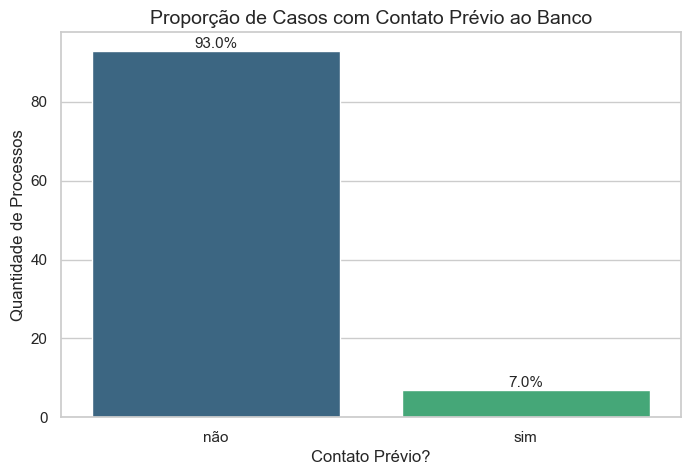

In [54]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df_curto, x='contato_previo_banco_ia', palette='viridis')
plt.title('Proporção de Casos com Contato Prévio ao Banco', fontsize=14)
plt.xlabel('Contato Prévio?', fontsize=12)
plt.ylabel('Quantidade de Processos', fontsize=12)

# Adicionar porcentagens acima das barras
total = len(df_curto['contato_previo_banco_ia'].dropna())
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height/total:.1%}', (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=11)
plt.show()


### 2. Canais de Contato Mais Utilizados

## Quando o cliente procura o banco, por onde ele vai?

C:\Users\Danilo\AppData\Local\Temp\ipykernel_23516\2291159057.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=canais, y='canal_contato_ia', order=canais['canal_contato_ia'].value_counts().index, palette='magma')


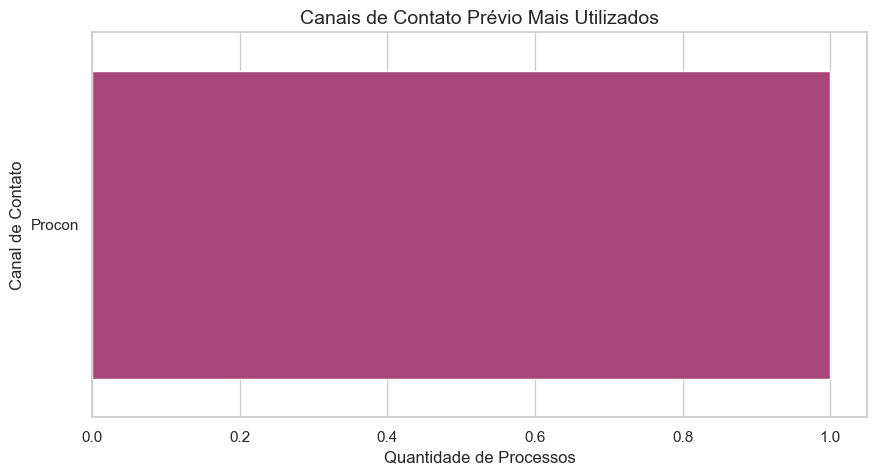

In [55]:
canais = df_curto[df_curto['canal_contato_ia'] != 'não identificado']

plt.figure(figsize=(10, 5))
ax = sns.countplot(data=canais, y='canal_contato_ia', order=canais['canal_contato_ia'].value_counts().index, palette='magma')
plt.title('Canais de Contato Prévio Mais Utilizados', fontsize=14)
plt.xlabel('Quantidade de Processos', fontsize=12)
plt.ylabel('Canal de Contato', fontsize=12)
plt.show()


### 3. Visão Geral dos Resultados e Valores

## Como se distribuem os resultados das sentenças e as indenizações?

C:\Users\Danilo\AppData\Local\Temp\ipykernel_23516\509519408.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_curto, y='resultado_julgamento_ia',


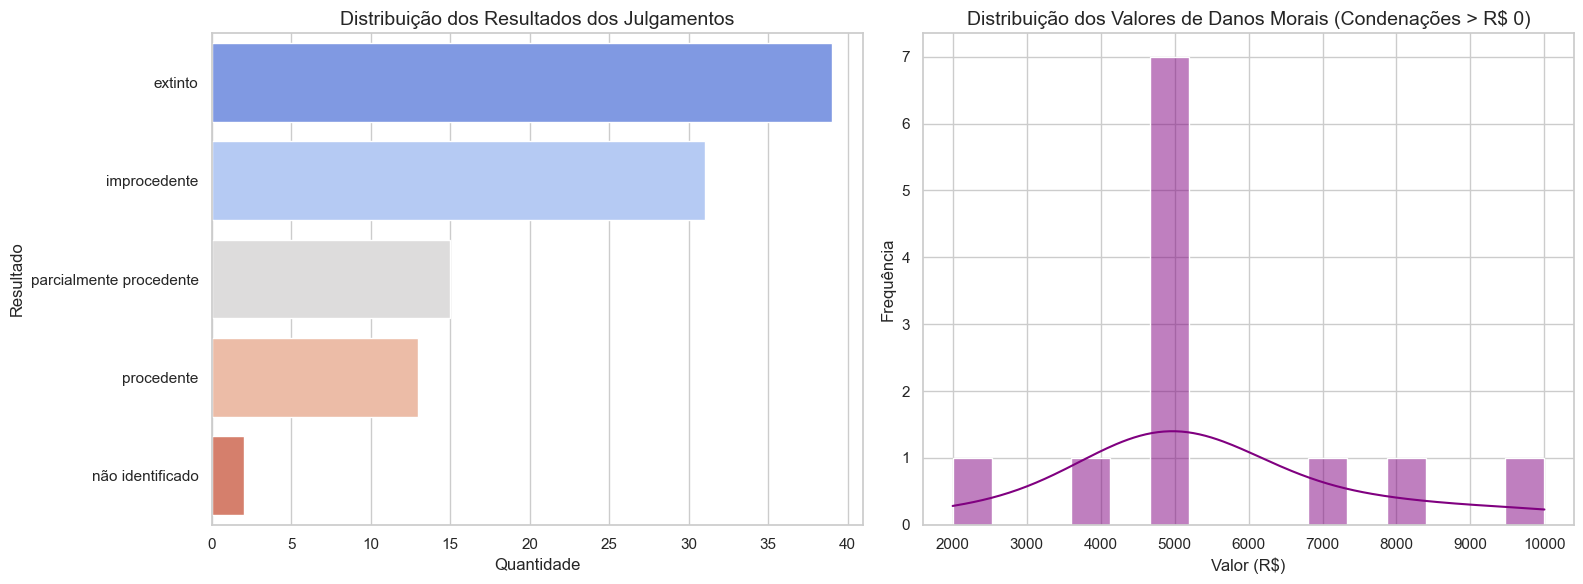

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Resultados
sns.countplot(data=df_curto, y='resultado_julgamento_ia', 
              order=df_curto['resultado_julgamento_ia'].value_counts().index, 
              palette='coolwarm', ax=axes[0])
axes[0].set_title('Distribuição dos Resultados dos Julgamentos', fontsize=14)
axes[0].set_xlabel('Quantidade', fontsize=12)
axes[0].set_ylabel('Resultado', fontsize=12)

# Valores de Danos Morais (apenas > 0)
danos_morais_positivos = df_curto[df_curto['valor_danos_morais_ia'] > 0]
sns.histplot(danos_morais_positivos['valor_danos_morais_ia'], bins=15, kde=True, color='purple', ax=axes[1])
axes[1].set_title('Distribuição dos Valores de Danos Morais (Condenações > R$ 0)', fontsize=14)
axes[1].set_xlabel('Valor (R$)', fontsize=12)
axes[1].set_ylabel('Frequência', fontsize=12)

plt.tight_layout()
plt.show()


### 4. Contato Prévio vs. Probabilidade de Vitória

## Clientes que tentaram resolver administrativamente têm taxa de procedência maior?

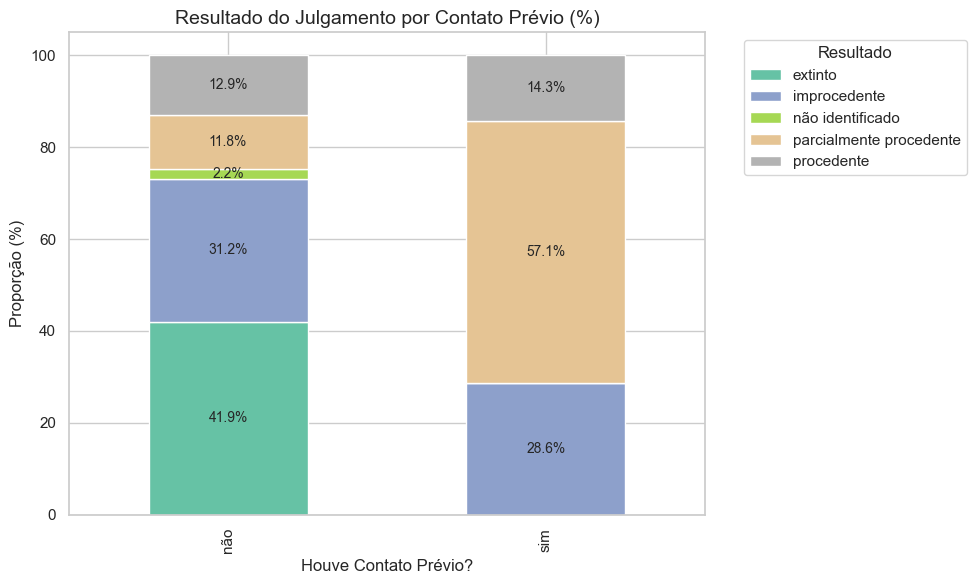

In [57]:
contato_resultado = pd.crosstab(df_curto['contato_previo_banco_ia'], df_curto['resultado_julgamento_ia'], normalize='index') * 100

ax = contato_resultado.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='Set2')
plt.title('Resultado do Julgamento por Contato Prévio (%)', fontsize=14)
plt.xlabel('Houve Contato Prévio?', fontsize=12)
plt.ylabel('Proporção (%)', fontsize=12)
plt.legend(title='Resultado', bbox_to_anchor=(1.05, 1), loc='upper left')

# Adicionar os valores nas barras
for c in ax.containers:
    labels = [f'{v.get_height():.1f}%' if v.get_height() > 0 else '' for v in c]
    ax.bar_label(c, labels=labels, label_type='center', fontsize=10)
    
plt.tight_layout()
plt.show()


### 5. Contato Prévio vs. Valores de Indenização (Danos Morais)

## Juízes aplicam indenizações maiores quando o cliente comprova que tentou contato?

C:\Users\Danilo\AppData\Local\Temp\ipykernel_23516\2799836589.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=condenados_morais, x='contato_previo_banco_ia', y='valor_danos_morais_ia', palette='Set3')


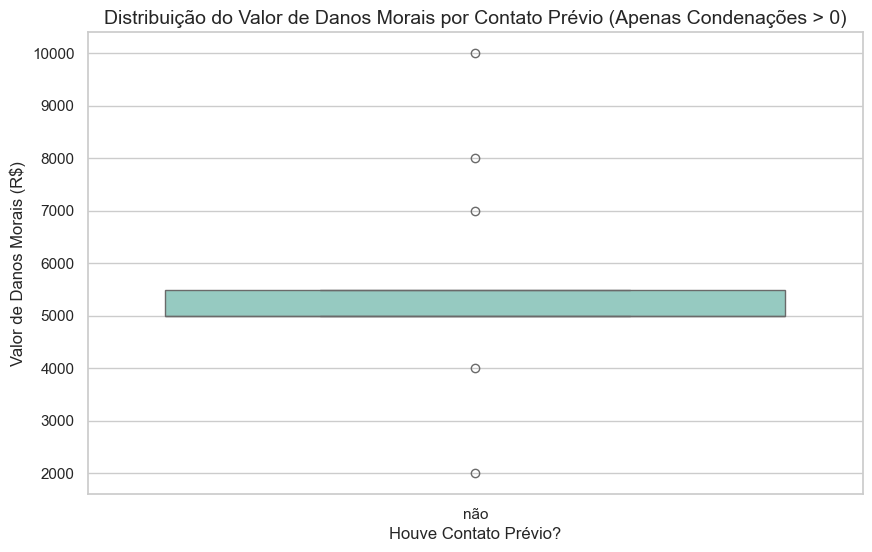

Média de Danos Morais (quando há condenação):
contato_previo_banco_ia
não    5500.0
Name: valor_danos_morais_ia, dtype: float64


In [58]:
plt.figure(figsize=(10, 6))
# Filtrar apenas quem ganhou danos morais
condenados_morais = df_curto[df_curto['valor_danos_morais_ia'] > 0]

sns.boxplot(data=condenados_morais, x='contato_previo_banco_ia', y='valor_danos_morais_ia', palette='Set3')
plt.title('Distribuição do Valor de Danos Morais por Contato Prévio (Apenas Condenações > 0)', fontsize=14)
plt.xlabel('Houve Contato Prévio?', fontsize=12)
plt.ylabel('Valor de Danos Morais (R$)', fontsize=12)
plt.show()

# Imprimir as médias
medias = condenados_morais.groupby('contato_previo_banco_ia')['valor_danos_morais_ia'].mean()
print("Média de Danos Morais (quando há condenação):")
print(medias)


### 6. Impacto do Canal de Contato no Resultado

## Acionar o Procon/Reclame Aqui gera maior probabilidade de vitória do que o SAC?

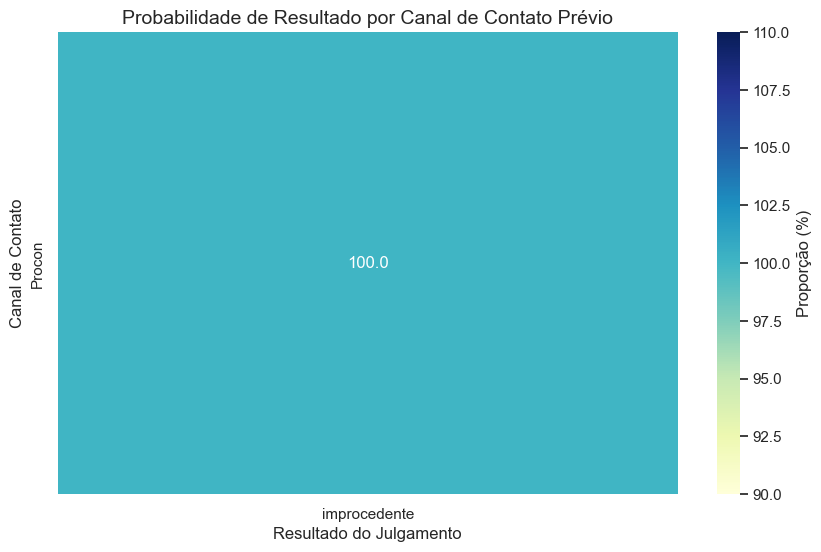

In [59]:
plt.figure(figsize=(10, 6))
canal_resultado = pd.crosstab(canais['canal_contato_ia'], canais['resultado_julgamento_ia'], normalize='index') * 100

sns.heatmap(canal_resultado, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={'label': 'Proporção (%)'})
plt.title('Probabilidade de Resultado por Canal de Contato Prévio', fontsize=14)
plt.ylabel('Canal de Contato', fontsize=12)
plt.xlabel('Resultado do Julgamento', fontsize=12)
plt.show()


### 7. Tipo de Ação vs. Contato Prévio

## Quais os tipos de ação com maior volume de tentativa prévia de acordo?

<Figure size 1000x600 with 0 Axes>

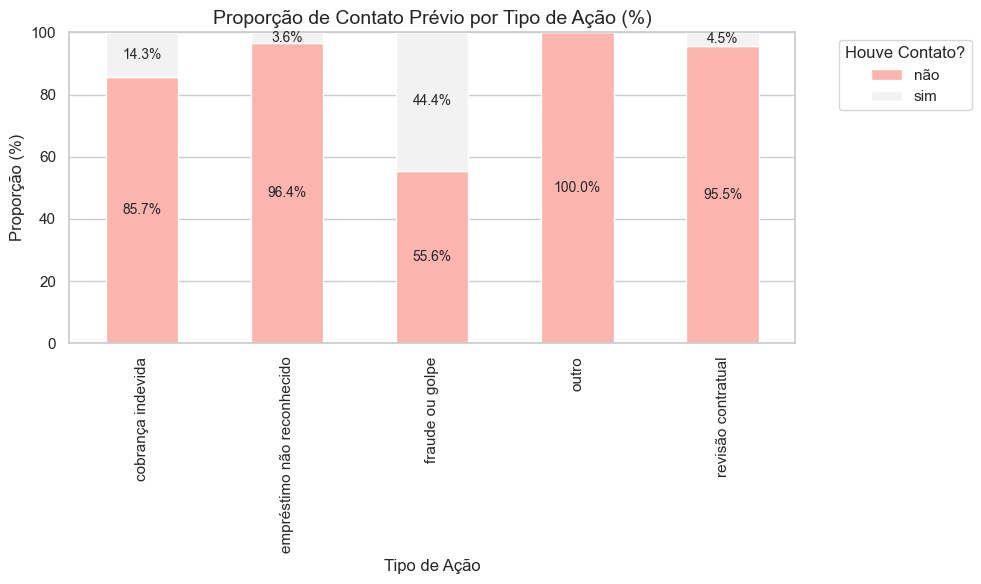

In [60]:
plt.figure(figsize=(10, 6))
tipo_contato = pd.crosstab(df_curto['tipo_acao_ia'], df_curto['contato_previo_banco_ia'], normalize='index') * 100

ax = tipo_contato.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='Pastel1')
plt.title('Proporção de Contato Prévio por Tipo de Ação (%)', fontsize=14)
plt.xlabel('Tipo de Ação', fontsize=12)
plt.ylabel('Proporção (%)', fontsize=12)
plt.legend(title='Houve Contato?', bbox_to_anchor=(1.05, 1), loc='upper left')

for c in ax.containers:
    labels = [f'{v.get_height():.1f}%' if v.get_height() > 0 else '' for v in c]
    ax.bar_label(c, labels=labels, label_type='center', fontsize=10)
    
plt.tight_layout()
plt.show()


### 8. Boletim de Ocorrência vs Probabilidade de Vitória

## Fazer B.O. ajuda a ganhar a causa?

<Figure size 1000x600 with 0 Axes>

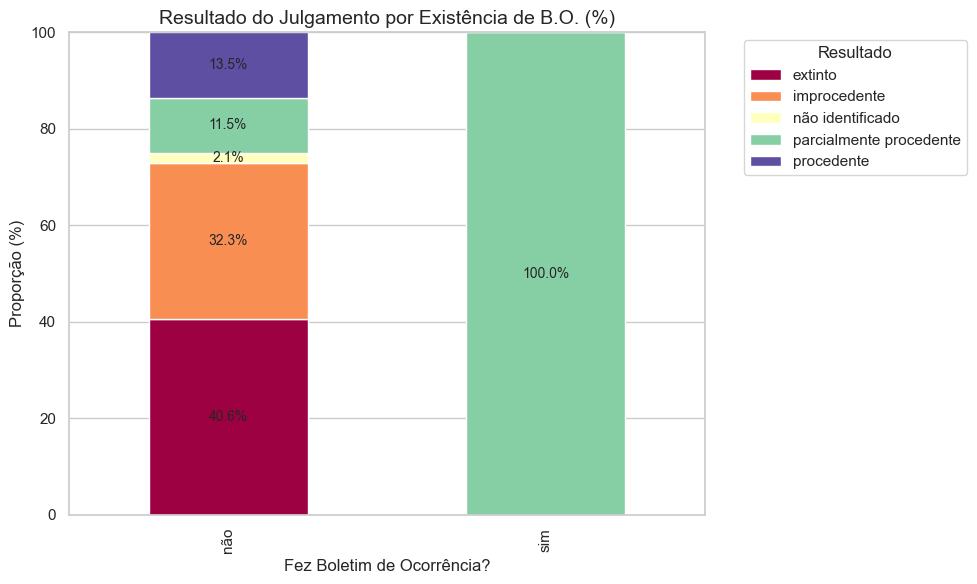

In [61]:
plt.figure(figsize=(10, 6))
bo_resultado = pd.crosstab(df_curto['boletim_de_ocorrencia_ia'], df_curto['resultado_julgamento_ia'], normalize='index') * 100

ax = bo_resultado.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='Spectral')
plt.title('Resultado do Julgamento por Existência de B.O. (%)', fontsize=14)
plt.xlabel('Fez Boletim de Ocorrência?', fontsize=12)
plt.ylabel('Proporção (%)', fontsize=12)
plt.legend(title='Resultado', bbox_to_anchor=(1.05, 1), loc='upper left')

for c in ax.containers:
    labels = [f'{v.get_height():.1f}%' if v.get_height() > 0 else '' for v in c]
    ax.bar_label(c, labels=labels, label_type='center', fontsize=10)
    
plt.tight_layout()
plt.show()


### 9. Atribuição de Culpa vs Contato Prévio

## Se houve contato, a culpa cai mais em cima do banco?

<Figure size 1000x600 with 0 Axes>

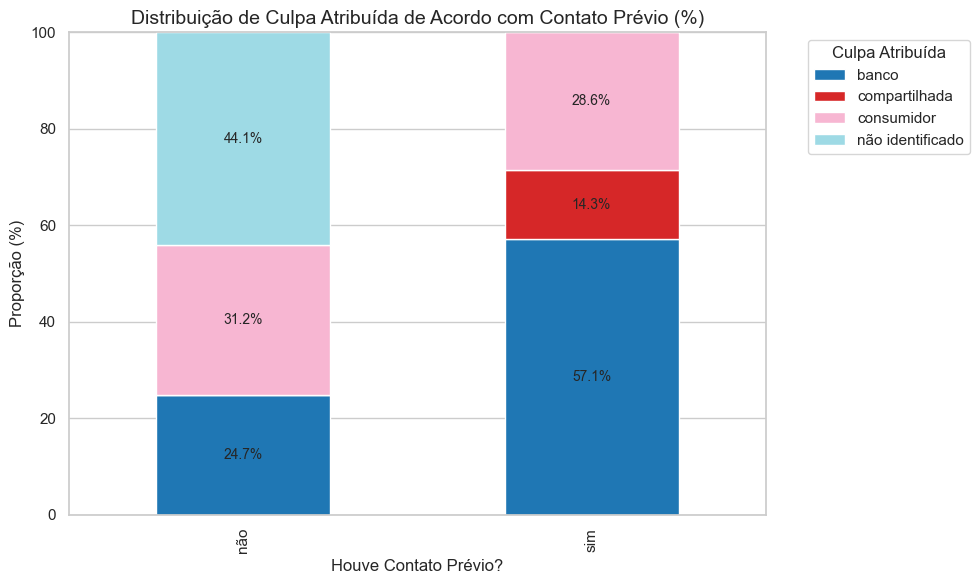

In [62]:
plt.figure(figsize=(10, 6))
culpa_contato = pd.crosstab(df_curto['culpa_atribuida_ia'], df_curto['contato_previo_banco_ia'], normalize='columns') * 100

ax = culpa_contato.T.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='tab20')
plt.title('Distribuição de Culpa Atribuída de Acordo com Contato Prévio (%)', fontsize=14)
plt.xlabel('Houve Contato Prévio?', fontsize=12)
plt.ylabel('Proporção (%)', fontsize=12)
plt.legend(title='Culpa Atribuída', bbox_to_anchor=(1.05, 1), loc='upper left')

for c in ax.containers:
    labels = [f'{v.get_height():.1f}%' if v.get_height() > 0 else '' for v in c]
    ax.bar_label(c, labels=labels, label_type='center', fontsize=10)
    
plt.tight_layout()
plt.show()


### 10. Tabela Resumo (Relatório 2)

In [63]:
# a) Porcentagem de processos com contato prévio
pct_contato = (df_curto['contato_previo_banco_ia'] == 'sim').mean() * 100

# b) Média de danos materiais (no subgrupo que fez contato)
subgrupo_contato = df_curto[df_curto['contato_previo_banco_ia'] == 'sim']
media_materiais_contato = subgrupo_contato['valor_danos_materiais_ia'].mean()

# c) Média de danos morais (no subgrupo que fez contato)
media_morais_contato = subgrupo_contato['valor_danos_morais_ia'].mean()

print(f"a) Porcentagem com contato prévio: {pct_contato:.2f}%")
print(f"b) Média de danos materiais (com contato): R$ {media_materiais_contato:.2f}")
print(f"c) Média de danos morais (com contato): R$ {media_morais_contato:.2f}")

# Montar o dataframe e salvar no relatorio.xlsx
df_relatorio = pd.DataFrame([{
    "porcentagem_contato_previo": pct_contato,
    "media_danos_materiais_com_contato": media_materiais_contato,
    "media_danos_morais_com_contato": media_morais_contato
}])

df_relatorio.to_excel("relatorio.xlsx", index=False)
print("\nArquivo relatorio.xlsx gerado com sucesso!")


a) Porcentagem com contato prévio: 7.00%
b) Média de danos materiais (com contato): R$ 1803.26
c) Média de danos morais (com contato): R$ 0.00

Arquivo relatorio.xlsx gerado com sucesso!
